<a href="https://colab.research.google.com/github/vishesh-banna0/Deep-Learning-Lab/blob/main/Lab5_RCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print(tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install opencv-contrib-python scikit-image

In [4]:
import cv2
import numpy as np
from skimage import data, img_as_ubyte

# Load a sample image
img = img_as_ubyte(data.astronaut())

# Create Selective Search object
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(img)
ss.switchToSelectiveSearchFast()  # fast mode (~2000 proposals)

# Run selective search
rects = ss.process()

print("Image shape:", img.shape)
print("Total region proposals:", len(rects))

Image shape: (512, 512, 3)
Total region proposals: 2081


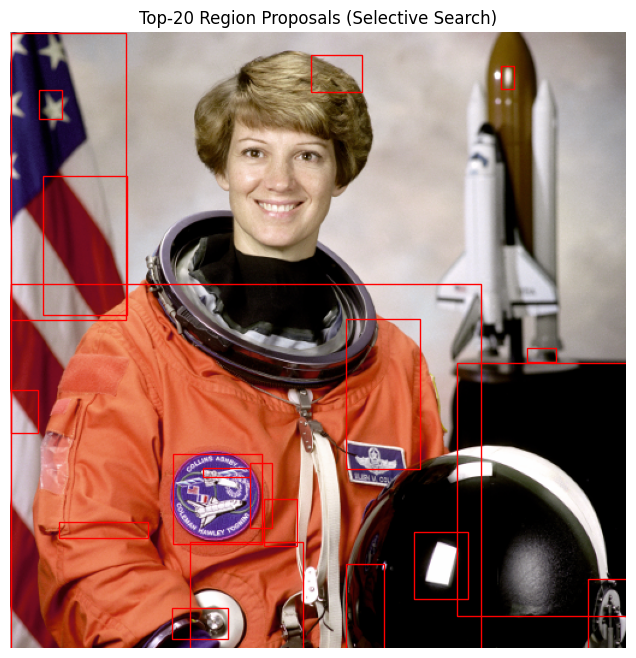

In [5]:
import matplotlib.pyplot as plt
import random

# Take first 20 proposals
proposals = rects[:20]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)

for (x, y, w, h) in proposals:
    ax.add_patch(
        plt.Rectangle(
            (x, y), w, h,
            fill=False,
            edgecolor='red',
            linewidth=1
        )
    )

ax.set_title("Top-20 Region Proposals (Selective Search)")
ax.axis("off")
plt.show()

In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

# Load VGG16 with ImageNet weights
base_model = VGG16(weights="imagenet", include_top=True)

# Remove final classification layer, keep fc2 (4096-d features)
feature_extractor = Model(
    inputs=base_model.input,
    outputs=base_model.get_layer("fc2").output
)

print("Feature extractor output shape:", feature_extractor.output_shape)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step
Feature extractor output shape: (None, 4096)


In [7]:
import cv2
import numpy as np
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

# Take ONE region proposal
x, y, w, h = rects[0]

# Crop region from image
roi = img[y:y+h, x:x+w]

# Resize to VGG16 input size
roi = cv2.resize(roi, (224, 224))

# Prepare for CNN
roi = img_to_array(roi)
roi = np.expand_dims(roi, axis=0)
roi = preprocess_input(roi)

# Extract features
features = feature_extractor.predict(roi)

print("Feature vector shape:", features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Feature vector shape: (1, 4096)


In [8]:
features_list = []
valid_boxes = []

for (x, y, w, h) in rects:
    # Skip very small regions
    if w < 20 or h < 20:
        continue

    roi = img[y:y+h, x:x+w]
    roi = cv2.resize(roi, (224, 224))

    roi = img_to_array(roi)
    roi = np.expand_dims(roi, axis=0)
    roi = preprocess_input(roi)

    feat = feature_extractor.predict(roi, verbose=0)
    features_list.append(feat[0])
    valid_boxes.append((x, y, w, h))

features_array = np.array(features_list)

print("Total valid regions:", len(valid_boxes))
print("Feature array shape:", features_array.shape)

Total valid regions: 1584
Feature array shape: (1584, 4096)


In [9]:
def compute_iou(boxA, boxB):
    # box format: (x, y, w, h)
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])

    inter_width = max(0, xB - xA)
    inter_height = max(0, yB - yA)
    inter_area = inter_width * inter_height

    areaA = boxA[2] * boxA[3]
    areaB = boxB[2] * boxB[3]

    union_area = areaA + areaB - inter_area

    return inter_area / union_area if union_area > 0 else 0

In [10]:
# Example ground-truth box (x, y, w, h)
gt_box = (170, 100, 200, 300)

In [11]:
labels = []

for box in valid_boxes:
    iou = compute_iou(box, gt_box)

    if iou >= 0.5:
        labels.append(1)   # positive
    elif iou < 0.3:
        labels.append(0)   # negative
    else:
        labels.append(-1)  # ignore

labels = np.array(labels)

print("Positive samples:", np.sum(labels == 1))
print("Negative samples:", np.sum(labels == 0))
print("Ignored samples:", np.sum(labels == -1))

Positive samples: 5
Negative samples: 1521
Ignored samples: 58


In [12]:
from sklearn.svm import LinearSVC

# Select valid samples (ignore label = -1)
mask = labels != -1
X_train = features_array[mask]
y_train = labels[mask]

print("Training samples:", X_train.shape)

Training samples: (1526, 4096)


In [13]:
svm = LinearSVC(max_iter=5000)
svm.fit(X_train, y_train)

print("SVM training completed")

SVM training completed


In [14]:
import numpy as np
from sklearn.linear_model import Ridge

# Select only positive samples
pos_mask = labels == 1
X_reg = features_array[pos_mask]
pos_boxes = np.array(valid_boxes)[pos_mask]

# Ground-truth box (same as before)
gt = np.array(gt_box)

# Compute regression targets
targets = []
for box in pos_boxes:
    px, py, pw, ph = box
    gx, gy, gw, gh = gt

    tx = (gx - px) / pw
    ty = (gy - py) / ph
    tw = np.log(gw / pw)
    th = np.log(gh / ph)

    targets.append([tx, ty, tw, th])

targets = np.array(targets)

print("Regression samples:", targets.shape)

Regression samples: (5, 4)


In [15]:
bbox_regressor = Ridge(alpha=1.0)
bbox_regressor.fit(X_reg, targets)

print("Bounding box regression training completed")

Bounding box regression training completed


In [16]:
# Predict object / background scores
scores = svm.decision_function(features_array)

print("Scores shape:", scores.shape)

Scores shape: (1584,)


In [17]:
refined_boxes = []

for i, box in enumerate(valid_boxes):
    x, y, w, h = box

    # Apply regression only if predicted as object
    if scores[i] > 0:
        tx, ty, tw, th = bbox_regressor.predict(
            features_array[i].reshape(1, -1)
        )[0]

        new_x = int(x + tx * w)
        new_y = int(y + ty * h)
        new_w = int(w * np.exp(tw))
        new_h = int(h * np.exp(th))

        refined_boxes.append((new_x, new_y, new_w, new_h))
    else:
        refined_boxes.append(box)

print("Total refined boxes:", len(refined_boxes))

Total refined boxes: 1584


In [18]:
def nms(boxes, scores, iou_thresh=0.3):
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes)
    scores = np.array(scores)

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 0] + boxes[:, 2]
    y2 = boxes[:, 1] + boxes[:, 3]

    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]

    keep = []

    while order.size > 0:
        i = order[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)
        inter = w * h

        iou = inter / (areas[i] + areas[order[1:]] - inter)
        inds = np.where(iou <= iou_thresh)[0]

        order = order[inds + 1]

    return keep

In [19]:
# Use only boxes predicted as object
object_indices = np.where(scores > 0)[0]

obj_boxes = [refined_boxes[i] for i in object_indices]
obj_scores = [scores[i] for i in object_indices]

keep_indices = nms(obj_boxes, obj_scores, iou_thresh=0.3)

final_boxes = [obj_boxes[i] for i in keep_indices]
final_scores = [obj_scores[i] for i in keep_indices]

print("Final detections after NMS:", len(final_boxes))

Final detections after NMS: 1


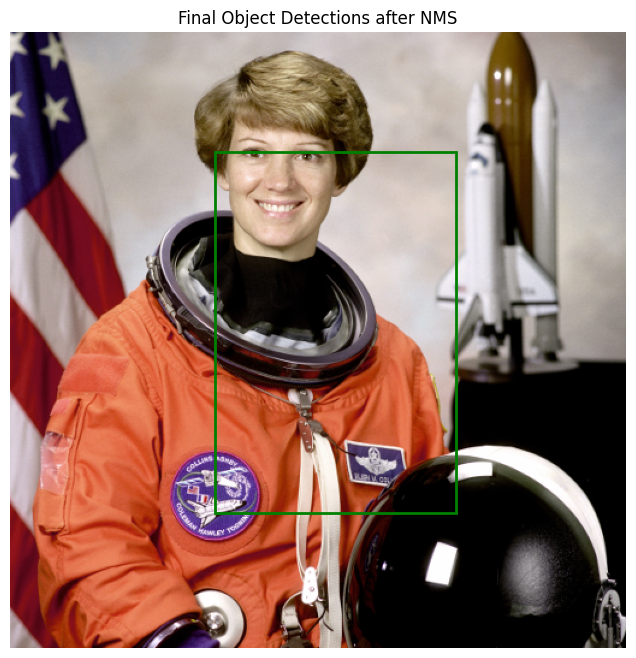

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)

for (x, y, w, h) in final_boxes:
    ax.add_patch(
        plt.Rectangle(
            (x, y), w, h,
            fill=False,
            edgecolor='green',
            linewidth=2
        )
    )

ax.set_title("Final Object Detections after NMS")
ax.axis("off")
plt.show()

In [21]:
ious = []

for box in final_boxes:
    ious.append(compute_iou(box, gt_box))

print("IoU values:", ious)
print("Average IoU:", np.mean(ious) if len(ious) > 0 else 0)

IoU values: [0.9933554817275747]
Average IoU: 0.9933554817275747
